Tại sao phần này quan trọng? Giảng viên sẽ đánh giá rất cao nếu bạn giải thích được: "Cụm 0 là các máy hoạt động ở tốc độ cao nhưng mô-men xoắn thấp" hoặc "Luật kết hợp cho thấy khi Torque cao kết hợp với Tool wear cao thì khả năng lỗi máy tăng gấp 5 lần (Lift > 5)".

In [ ]:
# =================================================================
# PHẦN 1: THIẾT LẬP VÀ PHÂN CỤM (CLUSTERING)
# Giữ nguyên logic gốc và bổ sung phần lưu trữ kết quả
# =================================================================

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import joblib # Bổ sung để lưu model
sys.path.append(os.path.abspath(".."))

from src.data.loader import load_config
from src.mining.clustering import perform_clustering

# 1. Load dữ liệu đã xử lý từ bước trước
config = load_config("../configs/params.yaml")
df_final = pd.read_csv("../data/processed/cleaned_data.csv")

# 2. Thực hiện phân cụm (Giữ nguyên hàm perform_clustering của bạn)
# Kết quả hiển thị Silhouette Score: 0.4262 như trong ảnh bạn gửi
df_clustered, model_kmeans = perform_clustering(df_final, config)

# --- BẮT ĐẦU PHẦN BỔ SUNG LƯU TRỮ ---

# 2.1. Lưu mô hình K-Means vào outputs/models
# Việc này giúp bạn không phải chạy lại thuật toán phân cụm ở các lần sau
joblib.dump(model_kmeans, "../outputs/models/kmeans_model.pkl")
print("💾 Đã lưu mô hình K-Means vào outputs/models/kmeans_model.pkl")

# 2.2. Hiển thị và lưu đặc điểm từng cụm (Kết quả như trong ảnh image_1f39ed.png)
cluster_stats = df_clustered.groupby('Cluster')[config['features']['numerical']].mean()
print("\nĐặc điểm trung bình các biến cảm biến theo từng cụm:")
display(cluster_stats)

# Lưu bảng thống kê này vào outputs/tables để đưa vào báo cáo
cluster_stats.to_csv("../outputs/tables/mining_cluster_characteristics.csv")
print("✅ Đã lưu bảng đặc trưng cụm vào outputs/tables/mining_cluster_characteristics.csv")

# 2.3. Lưu dữ liệu đã gán nhãn cụm để dùng cho các phần vẽ biểu đồ tiếp theo
df_clustered.to_csv("../data/processed/clustered_data.csv", index=False)
# --- KẾT THÚC PHẦN BỔ SUNG ---

✅ Phân cụm hoàn tất. Silhouette Score: 0.2622
💾 Đã lưu mô hình K-Means vào outputs/models/kmeans_model.pkl

Đặc điểm trung bình các biến cảm biến theo từng cụm:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Cluster,,,,,
0,0.859121,0.836465,-0.384709,0.366800,0.037820
1,-0.870270,-0.851972,-0.360514,0.328807,-0.052256
2,0.058222,0.065787,1.441837,-1.345515,0.029850


✅ Đã lưu bảng đặc trưng cụm vào outputs/tables/mining_cluster_characteristics.csv


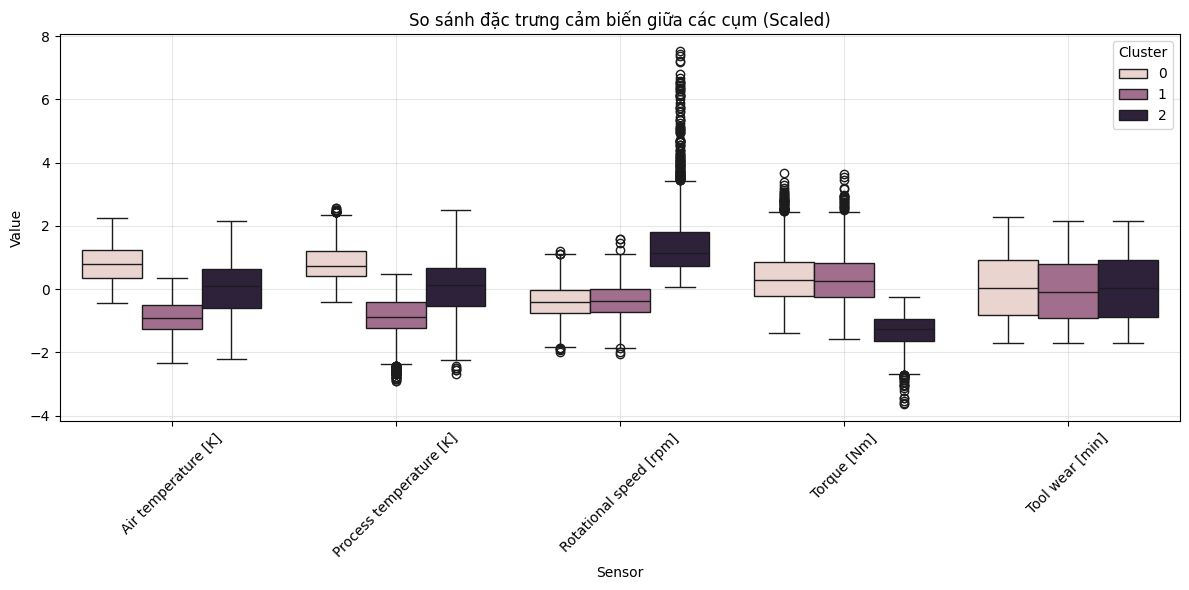

<Figure size 640x480 with 0 Axes>

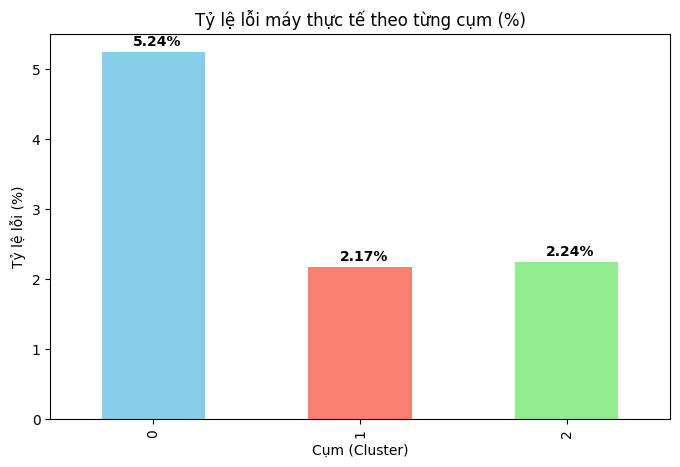

<Figure size 640x480 with 0 Axes>

Thống kê chi tiết theo cụm:


Machine failure                Air temperature [K] Tool wear [min]
                  count  sum      mean                mean            mean
Cluster                                                                   
0                  3930  206  0.052417            0.859121        0.037820
1                  4017   87  0.021658           -0.870270       -0.052256
2                  2053   46  0.022406            0.058222        0.029850

In [ ]:
# =================================================================
# PHẦN 2: TRỰC QUAN HÓA VÀ PHÂN TÍCH Ý NGHĨA CỤM
# =================================================================

from src.visualization.plots import plot_cluster_comparison, plot_failure_by_cluster

# 1. Vẽ biểu đồ so sánh đặc trưng (Biểu đồ 1)
# Giúp hiểu sự khác biệt về thông số vận hành giữa các cụm
plot_cluster_comparison(df_clustered, config)
plt.savefig("../outputs/figures/mining_cluster_comparison.png", bbox_inches='tight')
plt.show() # Đảm bảo biểu đồ hiện ra trong Notebook

# 2. Vẽ tỷ lệ lỗi máy (Biểu đồ 2) - PHỤC HỒI BIỂU ĐỒ BẠN ĐANG THIẾU
# Giúp xác định cụm nào có nguy cơ hỏng hóc cao nhất
plot_failure_by_cluster(df_clustered)
plt.savefig("../outputs/figures/mining_failure_by_cluster.png", bbox_inches='tight')
plt.show() # Đảm bảo biểu đồ hiện ra trong Notebook

# 3. Phân tích thống kê chi tiết cho báo cáo
summary = df_clustered.groupby('Cluster').agg({
    'Machine failure': ['count', 'sum', 'mean'],
    'Air temperature [K]': 'mean',
    'Tool wear [min]': 'mean'
})
print("Thống kê chi tiết theo cụm:")
display(summary)

# Lưu bảng thống kê vào outputs/tables
summary.to_csv("../outputs/tables/mining_detailed_cluster_summary.csv")

In [ ]:
# =================================================================
# PHẦN 3: KHAI PHÁ LUẬT KẾT HỢP (ASSOCIATION RULES)
# =================================================================

from src.mining.association import get_association_rules, get_specific_failure_rules, compare_failure_patterns

# 1. So sánh số lượng luật giữa các loại lỗi
print("\n--- Bảng so sánh số lượng luật giữa các loại lỗi ---")
summary_dict = compare_failure_patterns(df_final, config)

# KHẮC PHỤC LỖI: Chuyển dict thành DataFrame
summary_counts = pd.DataFrame(list(summary_dict.items()), columns=['Failure Type', 'Rule Count'])

# Bây giờ mới có thể lưu .to_csv
summary_counts.to_csv("../outputs/tables/failure_rules_comparison.csv", index=False)
display(summary_counts)

# 2. Xem chi tiết luật cho từng loại lỗi (Giữ đúng logic của bạn)
failure_list = ["OSF", "HDF", "PWF", "TWF", "RNF"]
titles = {
    "OSF": "Quá tải (Overstrain)",
    "HDF": "Tản nhiệt (Heat Dissipation)",
    "PWF": "Công suất (Power)",
    "TWF": "Mòn dụng cụ (Tool Wear)",
    "RNF": "Ngẫu nhiên (Random)"
}

for f_type in failure_list:
    print(f"\n--- Chi tiết luật cho lỗi {titles[f_type]} ({f_type}) ---")
    specific_rules = get_specific_failure_rules(df_final, config, failure_type=f_type)
    
    if specific_rules is not None and not specific_rules.empty:
        # Hiển thị tối đa 10 luật quan trọng nhất
        display(specific_rules.head(10))
        # Lưu file báo cáo chi tiết
        specific_rules.to_csv(f"../outputs/reports/rules_{f_type.lower()}.csv", index=False)
    else:
        print(f"Lưu ý: Không tìm thấy luật thỏa mãn điều kiện cho loại lỗi {f_type}")

print("\n✅ Hoàn tất: Đã sửa lỗi và lưu toàn bộ kết quả vào outputs/")


--- Bảng so sánh số lượng luật giữa các loại lỗi ---
--- ĐANG SO SÁNH PATTERN CỦA CÁC LOẠI LỖI ---
Lỗi HDF: Tìm thấy 460 luật.
Lỗi PWF: Tìm thấy 1102 luật.
Lỗi OSF: Tìm thấy 473 luật.
Lỗi TWF: Tìm thấy 905 luật.
Lỗi RNF: Tìm thấy 1056 luật.


,Failure Type,Rule Count
0,HDF,460
1,PWF,1102
2,OSF,473
3,TWF,905
4,RNF,1056



--- Chi tiết luật cho lỗi Quá tải (Overstrain) (OSF) ---


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1998,"(Torque [Nm]_Torque [Nm]_High, Rotational spee...","(Air temperature [K]_Air temperature [K]_High,...",0.1163,0.0049,0.0044,0.037833,7.721059,1.0,0.003830,1.034228,0.985045,0.037671,0.033095,0.467896
2125,"(Torque [Nm]_Torque [Nm]_High, Air temperature...",(Process temperature [K]_Process temperature [...,0.1197,0.0046,0.0041,0.034252,7.446152,1.0,0.003549,1.030704,0.983418,0.034110,0.029789,0.462778
1262,"(Torque [Nm]_Torque [Nm]_High, Tool wear [min]...","(Air temperature [K]_Air temperature [K]_High,...",0.1227,0.0049,0.0044,0.035860,7.318331,1.0,0.003799,1.032111,0.984107,0.035714,0.031112,0.466910
2014,"(Torque [Nm]_Torque [Nm]_High, Tool wear [min]...",(Rotational speed [rpm]_Rotational speed [rpm]...,0.1227,0.0049,0.0044,0.035860,7.318331,1.0,0.003799,1.032111,0.984107,0.035714,0.031112,0.466910
2143,"(Torque [Nm]_Torque [Nm]_High, Air temperature...",(Rotational speed [rpm]_Rotational speed [rpm]...,0.1261,0.0046,0.0041,0.032514,7.068234,1.0,0.003520,1.028852,0.982403,0.032385,0.028043,0.461909
1460,"(Torque [Nm]_Torque [Nm]_High, Air temperature...",(Process temperature [K]_Process temperature [...,0.1261,0.0046,0.0041,0.032514,7.068234,1.0,0.003520,1.028852,0.982403,0.032385,0.028043,0.461909
1992,"(Torque [Nm]_Torque [Nm]_High, Rotational spee...",(Process temperature [K]_Process temperature [...,0.1211,0.0052,0.0044,0.036334,6.987232,1.0,0.003770,1.032307,0.974948,0.036095,0.031296,0.441244
2124,"(Torque [Nm]_Torque [Nm]_High, Rotational spee...","(Air temperature [K]_Air temperature [K]_Low, ...",0.1245,0.0049,0.0041,0.032932,6.720761,1.0,0.003490,1.028986,0.972253,0.032721,0.028170,0.434833
1259,"(Torque [Nm]_Torque [Nm]_High, Air temperature...",(Process temperature [K]_Process temperature [...,0.1273,0.0052,0.0044,0.034564,6.646927,1.0,0.003738,1.030415,0.973478,0.034348,0.029518,0.440359
2008,"(Torque [Nm]_Torque [Nm]_High, Air temperature...",(Rotational speed [rpm]_Rotational speed [rpm]...,0.1273,0.0052,0.0044,0.034564,6.646927,1.0,0.003738,1.030415,0.973478,0.034348,0.029518,0.440359



--- Chi tiết luật cho lỗi Tản nhiệt (Heat Dissipation) (HDF) ---


...


--- Chi tiết luật cho lỗi Mòn dụng cụ (Tool Wear) (TWF) ---


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2794,(Rotational speed [rpm]_Rotational speed [rpm]...,"(Torque [Nm]_Torque [Nm]_High, TWF)",0.0238,0.0018,0.0004,0.016807,9.337068,1.0,0.000357,1.015263,0.914669,0.015873,0.015034,0.119514
2847,"(Air temperature [K]_Air temperature [K]_Low, ...",(Rotational speed [rpm]_Rotational speed [rpm]...,0.0194,0.0020,0.0003,0.015464,7.731959,1.0,0.000261,1.013675,0.887892,0.014218,0.013491,0.082732
2788,"(Torque [Nm]_Torque [Nm]_High, Air temperature...","(TWF, Rotational speed [rpm]_Rotational speed ...",0.0203,0.0026,0.0004,0.019704,7.578628,1.0,0.000347,1.017448,0.886037,0.017778,0.017149,0.086775
2708,"(Torque [Nm]_Torque [Nm]_Low, Rotational speed...","(TWF, Process temperature [K]_Process temperat...",0.0270,0.0025,0.0005,0.018519,7.407407,1.0,0.000432,1.016321,0.889003,0.017241,0.016059,0.109259
2622,"(Torque [Nm]_Torque [Nm]_Low, Tool wear [min]_...",(Rotational speed [rpm]_Rotational speed [rpm]...,0.1262,0.0010,0.0009,0.007132,7.131537,1.0,0.000774,1.006176,0.983953,0.007126,0.006138,0.453566
2915,"(Air temperature [K]_Air temperature [K]_Low, ...",(Rotational speed [rpm]_Rotational speed [rpm]...,0.1230,0.0008,0.0007,0.005691,7.113821,1.0,0.000602,1.004919,0.979964,0.005686,0.004895,0.440346
2719,"(Torque [Nm]_Torque [Nm]_Low, Rotational speed...","(TWF, Air temperature [K]_Air temperature [K]_...",0.0262,0.0027,0.0005,0.019084,7.068137,1.0,0.000429,1.016703,0.881618,0.017606,0.016428,0.102135
2675,(Rotational speed [rpm]_Rotational speed [rpm]...,"(Torque [Nm]_Torque [Nm]_High, TWF, Process te...",0.1481,0.0008,0.0008,0.005402,6.752194,1.0,0.000682,1.004627,1.000000,0.005402,0.004605,0.502701
2971,(Rotational speed [rpm]_Rotational speed [rpm]...,"(Torque [Nm]_Torque [Nm]_High, Air temperature...",0.1520,0.0006,0.0006,0.003947,6.578947,1.0,0.000509,1.003361,1.000000,0.003947,0.003349,0.501974
2844,(Rotational speed [rpm]_Rotational speed [rpm]...,"(Torque [Nm]_Torque [Nm]_Low, TWF)",0.0169,0.0028,0.0003,0.017751,6.339814,1.0,0.000253,1.015222,0.856746,0.015464,0.014993,0.062447



--- Chi tiết luật cho lỗi Ngẫu nhiên (Random) (RNF) ---


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3193,"(Torque [Nm]_Torque [Nm]_Low, Air temperature ...",(Rotational speed [rpm]_Rotational speed [rpm]...,0.0335,0.0002,0.0001,0.002985,14.925373,1.0,0.000093,1.002793,0.965339,0.002976,0.002786,0.251493
3184,(Rotational speed [rpm]_Rotational speed [rpm]...,"(RNF, Torque [Nm]_Torque [Nm]_Low, Tool wear [...",0.0268,0.0003,0.0001,0.003731,12.437811,1.0,0.000092,1.003444,0.944924,0.003704,0.003432,0.168532
2821,(Rotational speed [rpm]_Rotational speed [rpm]...,"(RNF, Process temperature [K]_Process temperat...",0.0062,0.0013,0.0001,0.016129,12.406948,1.0,0.000092,1.015072,0.925136,0.013514,0.014848,0.046526
2834,(Rotational speed [rpm]_Rotational speed [rpm]...,"(RNF, Tool wear [min]_Tool wear [min]_High, Pr...",0.0119,0.0007,0.0001,0.008403,12.004802,1.0,0.000092,1.007769,0.927740,0.008000,0.007709,0.075630
2837,(Rotational speed [rpm]_Rotational speed [rpm]...,"(RNF, Air temperature [K]_Air temperature [K]_...",0.0125,0.0007,0.0001,0.008000,11.428571,1.0,0.000091,1.007359,0.924051,0.007634,0.007305,0.075429
3180,"(Torque [Nm]_Torque [Nm]_Low, Tool wear [min]_...",(Rotational speed [rpm]_Rotational speed [rpm]...,0.0149,0.0006,0.0001,0.006711,11.185682,1.0,0.000091,1.006153,0.924373,0.006494,0.006115,0.086689
2825,(Rotational speed [rpm]_Rotational speed [rpm]...,"(RNF, Air temperature [K]_Air temperature [K]_...",0.0064,0.0014,0.0001,0.015625,11.160714,1.0,0.000091,1.014451,0.916264,0.012987,0.014245,0.043527
3173,(Rotational speed [rpm]_Rotational speed [rpm]...,"(RNF, Torque [Nm]_Torque [Nm]_Low)",0.0117,0.0008,0.0001,0.008547,10.683761,1.0,0.000091,1.007814,0.917130,0.008065,0.007753,0.066774
2818,(Rotational speed [rpm]_Rotational speed [rpm]...,(RNF),0.0053,0.0019,0.0001,0.018868,9.930487,1.0,0.000090,1.017294,0.904092,0.014085,0.017000,0.035750
3248,(Rotational speed [rpm]_Rotational speed [rpm]...,"(Air temperature [K]_Air temperature [K]_Low, ...",0.1009,0.0002,0.0002,0.001982,9.910803,1.0,0.000180,1.001786,1.000000,0.001982,0.001783,0.500991



✅ Hoàn tất: Đã sửa lỗi và lưu toàn bộ kết quả vào outputs/
